# Climate Trend Detection & Attribution

**Purpose:** Quantify observed climate signals from real datasets while practicing reproducible analysis.

**We will:**
- Analyze temperature/precipitation time series (global vs regional)
- Compute anomalies and estimate trends
- Report trend significance and magnitude (Mann–Kendall, Sen’s slope)

**By the end, you can:**
- Build a reproducible trend-analysis workflow (notebook + saved outputs)
- Explain “signal vs noise” in climate time series
- Interpret results with uncertainty (data is evidence, not truth)

# 1. What Does “Climate Trend” Mean?

## Weather vs Climate

**Weather** refers to short-term atmospheric conditions (hours to days).
**Climate** refers to long-term statistical properties of weather (typically ≥ 30 years).

_Key idea:_ Climate is the distribution of weather over time.

- A hot day ≠ climate change
- A persistent shift in 30-year averages → climate signal

_The following example uses synthetic data to illustrate conceptual differences between short-term variability and long-term climate trends:_

In [1]:
# do a "pip install -r requirements.txt" in terminal to install all required dependencies for the notebook

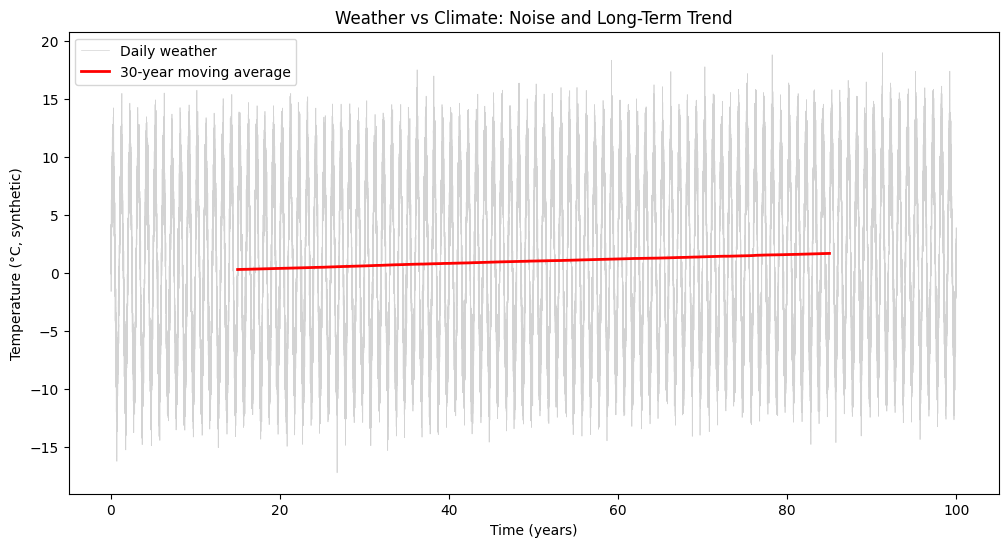

In [2]:
# Visualization idea (simple but powerful)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Generate synthetic climate data
# -----------------------------

np.random.seed(42)

years = 100
days_per_year = 365
total_days = years * days_per_year

time = np.arange(total_days)

# Convert to years for plotting
time_years = time / days_per_year

# Long-term warming trend (0.02 °C per year)
trend = 0.02 * time_years

# Seasonal cycle (±10°C)
seasonal = 10 * np.sin(2 * np.pi * time / days_per_year)

# Daily weather noise (random variability)
weather_noise = np.random.normal(0, 2, total_days)

# Combine components
temperature = trend + seasonal + weather_noise

# Create DataFrame
df = pd.DataFrame({
    "Year": time_years,
    "Temperature": temperature
})

# 30-year moving average (approximate, in days)
window = 30 * days_per_year
df["30yr_MA"] = df["Temperature"].rolling(window=window, center=True).mean()

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(12,6))
pip install -r requirements.txt
plt.plot(df["Year"], df["Temperature"], 
         color="lightgray", linewidth=0.5, label="Daily weather")

plt.plot(df["Year"], df["30yr_MA"], 
         color="red", linewidth=2, label="30-year moving average")

plt.xlabel("Time (years)")
plt.ylabel("Temperature (°C, synthetic)")
plt.title("Weather vs Climate: Noise and Long-Term Trend")
plt.legend()

plt.show()


## Why Do Climate Trends Require Long Time Spans?

Climate signals are small compared to short-term variability.

Example:
- Daily temperature variability: ±10°C
- Long-term warming trend: ~0.02°C per year

If you only look at 5 years:
- Natural variability dominates
- Trend may look flat or even reversed

If you look at 50–100 years:
- Signal emerges from noise

Next visualization will show:
- Over 10 years → noise dominates, trend may look weak or ambiguous
- Over 100 years → signal clearly emerges


_Plot showing 10-year vs 100-year subset of the same synthetic data:_

Estimated trend (10 years):  -0.1774 °C/year
Estimated trend (100 years): 0.0177 °C/year


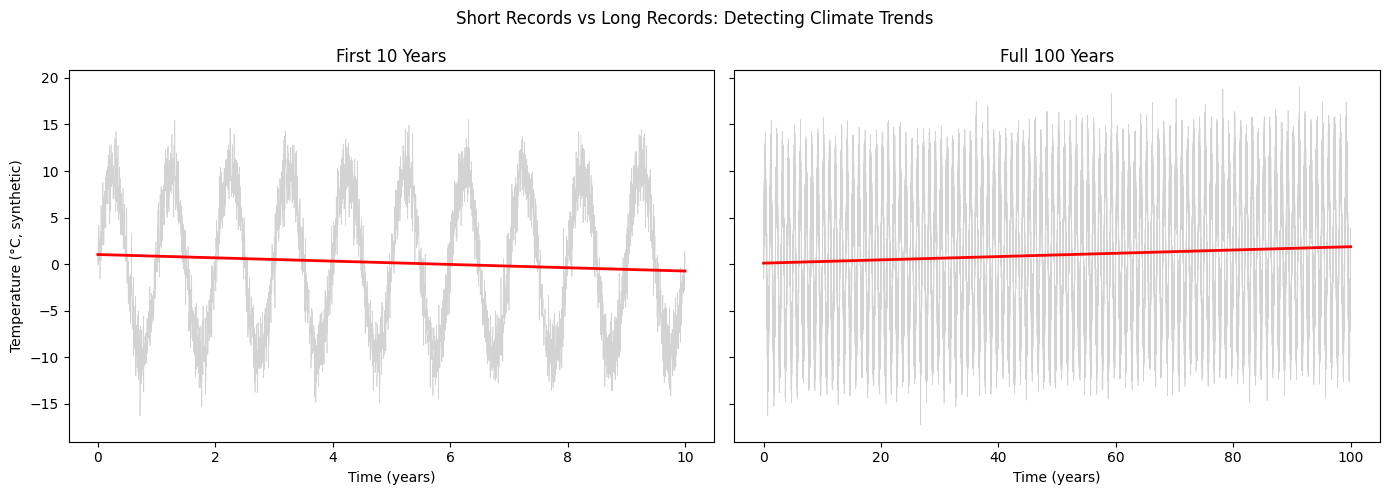

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Select subsets ---
df_10 = df[df["Year"] <= 10]
df_100 = df

# --- Linear fits ---
coef_10 = np.polyfit(df_10["Year"], df_10["Temperature"], 1)
coef_100 = np.polyfit(df_100["Year"], df_100["Temperature"], 1)

trend_10 = np.poly1d(coef_10)
trend_100 = np.poly1d(coef_100)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# 10-year view
axes[0].plot(df_10["Year"], df_10["Temperature"], 
             color="lightgray", linewidth=0.5)
axes[0].plot(df_10["Year"], trend_10(df_10["Year"]), 
             color="red", linewidth=2)

axes[0].set_title("First 10 Years")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Temperature (°C, synthetic)")

# 100-year view
axes[1].plot(df_100["Year"], df_100["Temperature"], 
             color="lightgray", linewidth=0.5)
axes[1].plot(df_100["Year"], trend_100(df_100["Year"]), 
             color="red", linewidth=2)

axes[1].set_title("Full 100 Years")
axes[1].set_xlabel("Time (years)")

plt.suptitle("Short Records vs Long Records: Detecting Climate Trends")
plt.tight_layout()
plt.show

print(f"Estimated trend (10 years):  {coef_10[0]:.4f} °C/year")
print(f"Estimated trend (100 years): {coef_100[0]:.4f} °C/year")

## Why Use Anomalies Instead of Absolute Temperatures?

Absolute temperature varies strongly by location:
- Sahara ≠ Scandinavia
- Summer ≠ winter

To compare across space and time, we use: 
_Temperature anomaly = observed temperature − baseline average_

This:
- Removes seasonal cycles
- Allows regional comparison
- Reduces bias from station differences

**Now, using randomly generated data demonstrate:** Absolute temperature contains large seasonal structure that hides small long-term changes.
Anomalies remove predictable structure and make trends comparable across space.

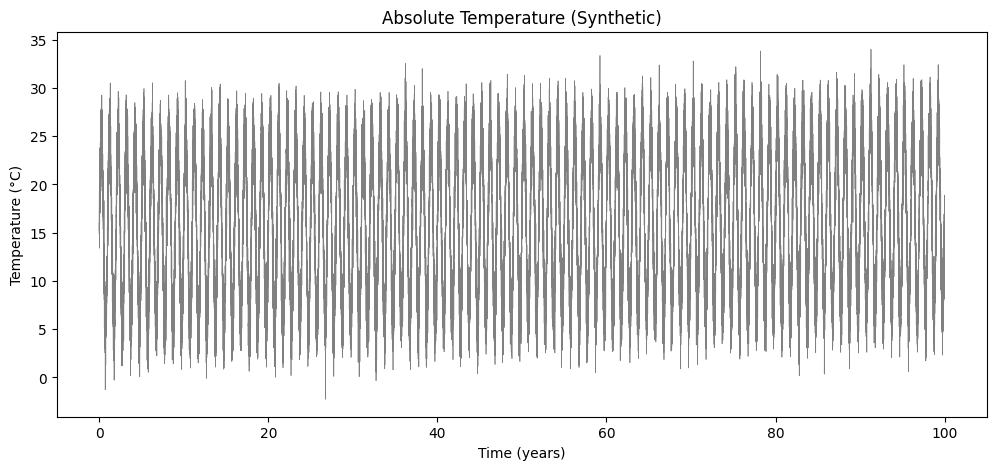

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

years = 100
days_per_year = 365
total_days = years * days_per_year

time = np.arange(total_days)
time_years = time / days_per_year

# Long-term warming trend
trend = 0.02 * time_years  # 0.02 °C per year

# Strong seasonal cycle
seasonal = 10 * np.sin(2 * np.pi * time / days_per_year)

# Weather noise
noise = np.random.normal(0, 2, total_days)

temperature = 15 + trend + seasonal + noise  # 15°C baseline

df = pd.DataFrame({
    "Year": time_years,
    "Day": time % days_per_year,
    "Temperature": temperature
})

# 
plt.figure(figsize=(12,5))
plt.plot(df["Year"], df["Temperature"], color="gray", linewidth=0.5)
plt.title("Absolute Temperature (Synthetic)")
plt.xlabel("Time (years)")
plt.ylabel("Temperature (°C)")
plt.show()


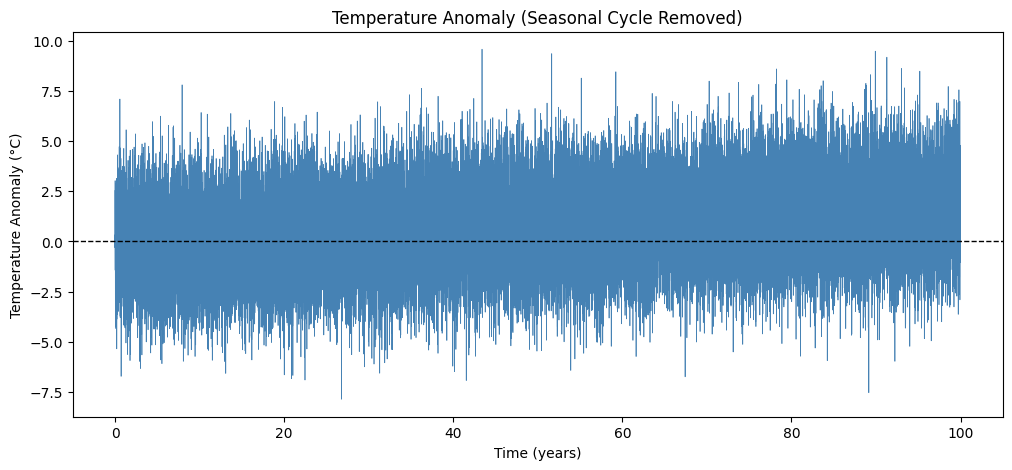

In [2]:
# Compute Climatology (Baseline Seasonal Cycle)
baseline = df[df["Year"] < 30]

# Compute average temperature for each day-of-year
climatology = baseline.groupby("Day")["Temperature"].mean()

# Now subtract seasonal cycle
df["Climatology"] = df["Day"].map(climatology)
df["Anomaly"] = df["Temperature"] - df["Climatology"]

# Plot Anomalies
plt.figure(figsize=(12,5))
plt.plot(df["Year"], df["Anomaly"], color="steelblue", linewidth=0.5)
plt.title("Temperature Anomaly (Seasonal Cycle Removed)")
plt.xlabel("Time (years)")
plt.ylabel("Temperature Anomaly (°C)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

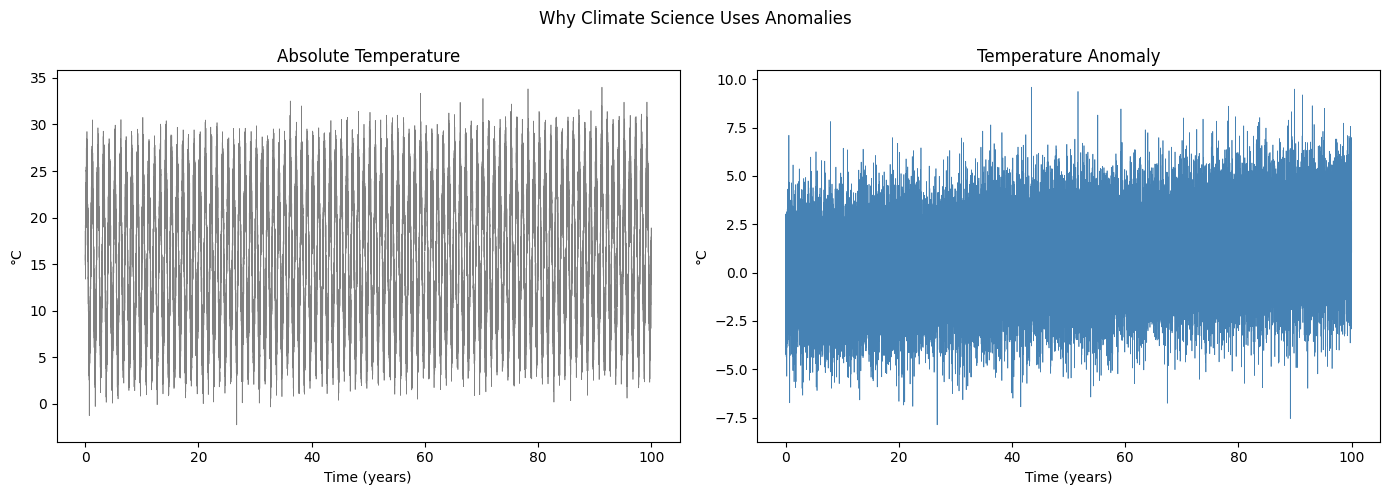

In [3]:
# Comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)

axes[0].plot(df["Year"], df["Temperature"], color="gray", linewidth=0.5)
axes[0].set_title("Absolute Temperature")

axes[1].plot(df["Year"], df["Anomaly"], color="steelblue", linewidth=0.5)
axes[1].set_title("Temperature Anomaly")

for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("°C")

plt.suptitle("Why Climate Science Uses Anomalies")
plt.tight_layout()
plt.show()

- Seasonal variability dominates absolute temperature.
- Anomalies remove predictable seasonal structure.
- Anomalies allow comparison across regions.
- Trends become easier to detect statistically.
  
*Most global temperature datasets (e.g., GISTEMP) are provided as anomalies for these reasons.*

## Monotonic Trend 

A monotonic trend means:
- Data consistently increases (or decreases) over time
- It does not require linearity

Example based on generated:
*signal=log(t)+noise*

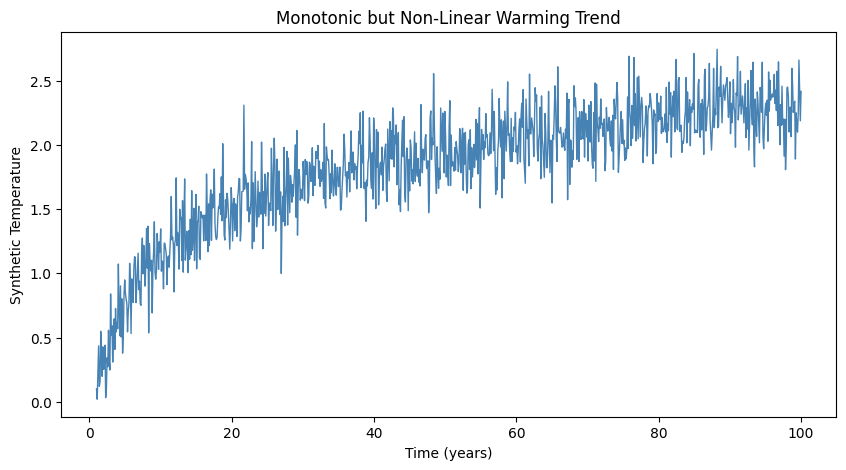

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

years = np.linspace(1, 100, 1000)

# Non-linear increasing trend
trend = 0.5 * np.log(years)

# Add variability
noise = np.random.normal(0, 0.2, len(years))

temperature = trend + noise

plt.figure(figsize=(10,5))
plt.plot(years, temperature, color="steelblue", linewidth=1)

plt.xlabel("Time (years)")
plt.ylabel("Synthetic Temperature")
plt.title("Monotonic but Non-Linear Warming Trend")

plt.show()

This time series shows a monotonic (consistently increasing) trend that is not linear.
Statistical methods like Mann–Kendall test for monotonic change, not strict linearity.

## Internal Variability

Internal variability refers to natural fluctuations within the climate system:
- ENSO
- Volcanic eruptions
- Ocean-atmosphere interactions

_Important idea_: Even without human forcing, the climate system is not static.

**Example:**

using synthetic example of 
_Trend (forced warming) + low-frequency oscillation (ENSO/AMO-like) + weather noise_

to show that _even with a real warming trend, the climate system naturally wiggles up/down for years or decades._


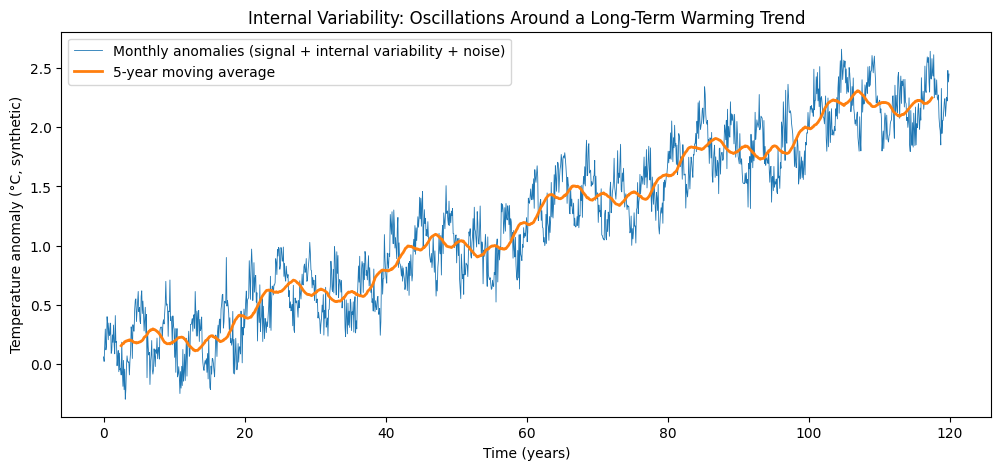

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Monthly data over 120 years
years = 120
n = years * 12
t_months = np.arange(n)
t_years = t_months / 12

# Forced signal: gradual warming (e.g., 0.02 °C / year)
forced_trend = 0.02 * t_years

# Internal variability: multi-year oscillation (ENSO-like ~4 years)
enso_like = 0.25 * np.sin(2 * np.pi * t_years / 4.0)

# Internal variability: decadal oscillation (AMO/PDO-like ~20 years)
decadal_like = 0.15 * np.sin(2 * np.pi * t_years / 20.0)

# High-frequency "weather" noise
weather_noise = np.random.normal(0, 0.12, n)

# Combine (anomaly-style series centered near 0)
temp_anomaly = forced_trend + enso_like + decadal_like + weather_noise

df_var = pd.DataFrame({"Year": t_years, "Anomaly": temp_anomaly})

# Smooth to highlight multi-year variability (5-year moving average)
df_var["5yr_MA"] = df_var["Anomaly"].rolling(window=5*12, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(df_var["Year"], df_var["Anomaly"], linewidth=0.6, label="Monthly anomalies (signal + internal variability + noise)")
plt.plot(df_var["Year"], df_var["5yr_MA"], linewidth=2, label="5-year moving average")
plt.xlabel("Time (years)")
plt.ylabel("Temperature anomaly (°C, synthetic)")
plt.title("Internal Variability: Oscillations Around a Long-Term Warming Trend")
plt.legend()
plt.show()


- The trend is the long-term forced signal.
- The oscillations represent internal climate variability (multi-year to decadal).
- Over short windows (e.g., 10 years), internal variability can mask or exaggerate the trend.

Short periods can mislead:

In [6]:
for start, end in [(0, 10), (30, 40), (70, 80)]:
    subset = df_var[(df_var["Year"] >= start) & (df_var["Year"] < end)]
    slope = np.polyfit(subset["Year"], subset["Anomaly"], 1)[0]
    print(f"Estimated slope from year {start} to {end}: {slope:.3f} °C/year")

Estimated slope from year 0 to 10: 0.024 °C/year
Estimated slope from year 30 to 40: 0.016 °C/year
Estimated slope from year 70 to 80: 0.017 °C/year


## Observational Uncertainty

All datasets have limitations:
- Sparse station coverage (early 1900s)
- Instrument biases
- Urban heat effects
- Reanalysis model assumptions

_Important distinction_: Uncertainty does not mean “we know nothing” — it means we quantify confidence.

Later, this links to:
- Confidence intervals
- Trend significance
- Policy interpretation

# 2. Data Source A: Global Temperature – NASA GISTEMP

## What Does GISTEMP Measure?

NASA GISTEMP provides estimates of global surface temperature anomalies based on:
- Land-based meteorological stations
- Sea surface temperature measurements
- Spatial interpolation to account for incomplete coverage

The dataset reports temperature anomalies, not absolute temperatures.
    
    Temperature anomaly = observed temperature − baseline climatology.

This allows:
- Cross-regional comparison
- Reduced bias from station-specific conditions
- Clearer detection of long-term change

## Spatial and Temporal Coverage

GISTEMP provides:
- Monthly and annual data
- Global mean temperature anomalies
- Gridded temperature anomaly maps
- Coverage extending back to the late 19th century (~1880)

Important characteristics:
- Early data is sparse
- Coverage improves significantly after ~1950
- Polar regions historically under-sampled

## Strengths and Limitations

Strengths:
- Long historical record (~140+ years)
- Global aggregation
- Transparent methodology
- Widely used in peer-reviewed research

Limitations:
- Sparse early station coverage
- Interpolation assumptions
- Changes in measurement technology over time
- Urban heat island corrections required

    **Observational datasets are estimates, not direct thermometers of the planet.**

## Step 1: Download Data

We begin with the global mean temperature anomaly dataset (L-OTI), which combines land-surface air temperatures and sea-surface temperatures into a unified global index. This dataset is widely used in climate science and provides one of the longest continuous global temperature records available.

The download link for _Global-mean monthly, seasonal, and annual means, 1880-present, updated through most recent month:_ under _Combined Land-Surface Air and Sea-Surface Water Temperature Anomalies (Land-Ocean Temperature Index, L-OTI)_ on https://data.giss.nasa.gov/gistemp/

We can either download the csv file in the notebook folder and read the file or access the data directly from the link:

In [28]:
import pandas as pd

url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

df_raw = pd.read_csv(url, skiprows=1)

df_raw.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-.25,-.10,-.17,-.11,-.22,-.19,-.11,-.15,-.24,-.23,-.18,-.18,***,***,-.13,-.17,-.21
1,1881,-0.21,-.15,.02,.04,.05,-.20,-.01,-.04,-.16,-.22,-.19,-.08,-.10,-.10,-.18,.04,-.08,-.19
2,1882,0.15,.13,.04,-.18,-.15,-.24,-.17,-.08,-.15,-.24,-.17,-.37,-.12,-.09,.07,-.10,-.16,-.19
3,1883,-0.30,-.37,-.13,-.19,-.18,-.07,-.08,-.14,-.22,-.11,-.25,-.12,-.18,-.20,-.35,-.17,-.10,-.19
4,1884,-0.14,-.09,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.34,-.31,-.29,-.27,-.11,-.37,-.31,-.29


## Step 2: Load and Clean Data

Tasks:
- Load file into pandas
- Remove header rows if necessary
- Convert year/month to datetime index
- Handle missing values

In [29]:
# Keep Only Monthly Columns
monthly_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df = df_raw[["Year"] + monthly_cols].copy()

# Reshape Wide → Long
df_long = df.melt(id_vars="Year",
                  value_vars=monthly_cols,
                  var_name="Month",
                  value_name="Anomaly")

df_long.head()

,Year,Month,Anomaly
0,1880,Jan,-0.19
1,1881,Jan,-0.21
2,1882,Jan,0.15
3,1883,Jan,-0.3
4,1884,Jan,-0.14


In [30]:
# Convert Anomalies to Numeric
df_long["Anomaly"] = pd.to_numeric(df_long["Anomaly"], errors="coerce")

#Convert Month Names to Numbers
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df_long["Month"] = df_long["Month"].map(month_map)

In [49]:
# Create Datetime Column
df_long["Date"] = pd.to_datetime(
    dict(year=df_long["Year"],
         month=df_long["Month"],
         day=1)
)

# Set Date as index (this is the key step)
df_long = df_long.set_index("Date").sort_index()

# Clean DataFrame
df_clean = df_long[["Anomaly"]].copy()

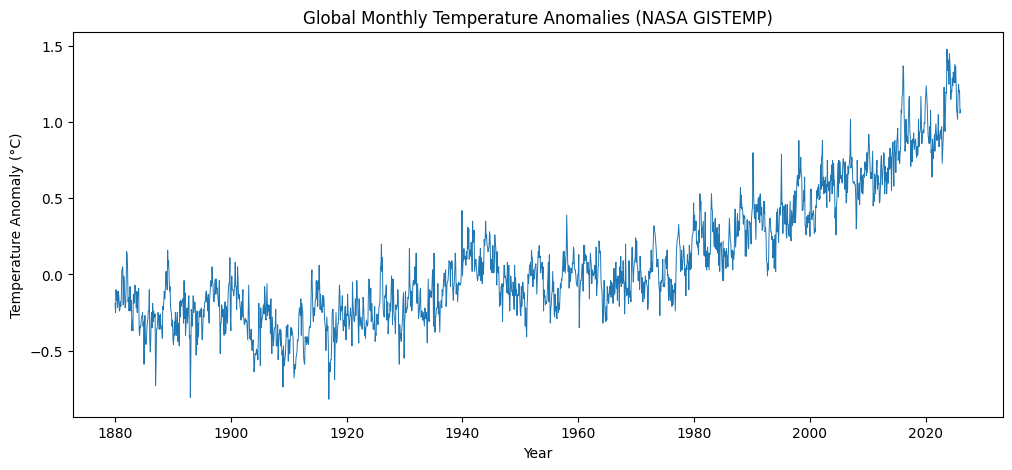

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_clean.index, df_clean["Anomaly"], linewidth=0.7)
plt.title("Global Monthly Temperature Anomalies (NASA GISTEMP)")
plt.ylabel("Temperature Anomaly (°C)")
plt.xlabel("Year")
plt.show()

## Smoothing Short-Term Variability: Rolling Means

Monthly temperature anomalies exhibit substantial short-term variability 
due to internal climate fluctuations (e.g., ENSO) and other transient factors.

To better visualize the long-term climate signal, we compute moving averages:

- A 5-year rolling mean (60 months)
- A 10-year rolling mean (120 months)

These smoothed series reduce high-frequency variability while preserving 
the underlying long-term trend.

Importantly, smoothing does not create a trend — it only reveals persistent 
structure already present in the data.


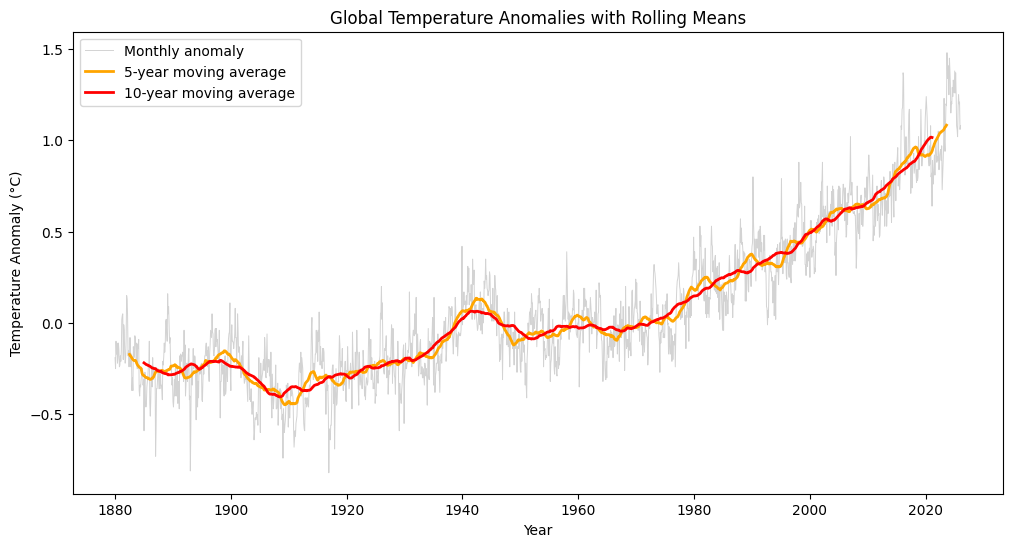

In [45]:
df_clean["5yr_MA"] = df_clean["Anomaly"].rolling(window=60, center=True).mean()
df_clean["10yr_MA"] = df_clean["Anomaly"].rolling(window=120, center=True).mean()

plt.figure(figsize=(12,6))

plt.plot(df_clean.index, df_clean["Anomaly"], 
         color="lightgray", linewidth=0.7, label="Monthly anomaly")

plt.plot(df_clean.index, df_clean["5yr_MA"], 
         color="orange", linewidth=2, label="5-year moving average")

plt.plot(df_clean.index, df_clean["10yr_MA"], 
         color="red", linewidth=2, label="10-year moving average")

plt.title("Global Temperature Anomalies with Rolling Means")
plt.ylabel("Temperature Anomaly (°C)")
plt.xlabel("Year")
plt.legend()

plt.show()


Several features become clear after smoothing:

- The long-term warming trend is evident across the entire record.
- Short-term cooling periods (e.g., early 20th century, mid-century plateau) do not contradict the long-term upward trend.
- The rate of warming appears to accelerate after the 1970s.

This demonstrates a key principle in climate analysis:

Short-term variability can obscure long-term trends, but it does not negate them.

The next step is to formally quantify this trend using statistical methods.

In [48]:
import numpy as np

df_annual = df_clean["Anomaly"].resample("YE").mean()

# Create decimal year axis
years = df_clean.index.year + (df_clean.index.month - 1)/12

# Remove missing values
mask = ~df_clean["Anomaly"].isna()

years_valid = years[mask]
anomaly_valid = df_clean["Anomaly"][mask]

# Fit linear trend
coef = np.polyfit(years_valid, anomaly_valid, 1)

print(f"Estimated warming rate: {coef[0]:.4f} °C per year")
print(f"≈ {coef[0]*10:.3f} °C per decade")

Estimated warming rate: 0.0084 °C per year
≈ 0.084 °C per decade


## Initial Uncertainty Discussion

**Measurement Gaps**

Early data (~1880–1920):
- Sparse spatial coverage
- More uncertainty
- Less representation of polar regions

**Station Coverage Bias**
- Land areas better sampled than oceans historically
- Urbanization effects
- Homogenization adjustments applied

**Why Uncertainty Grows Backward in Time**
- Fewer measurements
- Larger interpolation regions
- Greater reliance on statistical reconstruction

    *Confidence in the trend increases as station density improves.*


### Suggested discussions:
- Who produced this dataset?
- What assumptions were made?
- What corrections were applied?
- What uncertainties remain?



# 3. Trend Detection on Global Data

## Visual Trend Intuition
Before applying formal statistical tests, we begin with a simple visual inspection of the data.

The smoothed temperature anomaly series suggests a long-term upward trend.
However, visual inspection alone is insufficient for scientific inference.

A linear regression provides a first quantitative estimate of the warming rate.

In [51]:
# TODO:
# - Use annual anomalies (recommended)
# - Fit a linear regression (np.polyfit or similar)
# - Plot regression line over data
# - Print slope in °C/year and °C/decade

Linear regression estimates the best-fitting straight line through the data.

However:
- It assumes a linear relationship.
- It is sensitive to outliers.
- It assumes independent residuals.
- Climate time series are autocorrelated.

Most importantly: _A visually convincing slope does not automatically imply statistical significance._

This motivates the use of non-parametric trend tests.

## Mann–Kendall Trend Test

The Mann–Kendall test is a **non-parametric statistical test** used to detect monotonic trends in time series.

It answers the question: _Is there a consistent upward or downward tendency over time?_

It does **not** assume:
- Linearity
- Normality
- Specific distribution

It tests whether later observations tend to be larger than earlier ones.

Next section would require pymannkendall (https://pypi.org/project/pymannkendall/) installed: 
    sudo pip install pymannkendall   



In [55]:
import pymannkendall as mk

df_annual = df_clean["Anomaly"].resample("YE").mean().dropna()

# Run Mann–Kendall test on annual anomalies
mk_result = mk.original_test(df_annual.values)

print("Mann–Kendall Test Results:")
print("---------------------------")
print(f"Trend: {mk_result.trend}")
print(f"Hypothesis (h): {mk_result.h}")
print(f"p-value: {mk_result.p:.5f}")
print(f"Z-score: {mk_result.z:.3f}")
print(f"Kendall's tau: {mk_result.Tau:.4f}")
print(f"Sen's slope: {mk_result.slope:.5f} °C/year")
print(f"≈ {mk_result.slope * 10:.3f} °C/decade")

Mann–Kendall Test Results:
---------------------------
Trend: increasing
Hypothesis (h): True
p-value: 0.00000
Z-score: 13.188
Kendall's tau: 0.7339
Sen's slope: 0.00827 °C/year
≈ 0.083 °C/decade


- **Trend**: Direction of monotonic change (increasing / decreasing / no trend)
- **h**: Hypothesis test result (True = significant trend detected)
- **p-value**: Probability of observing this pattern if no trend exists
- **Z-score**: Standardized test statistic (|Z| > 1.96 → significant at 95%; |Z| > 2.58 → significant at 99%)
- **Kendall’s tau**: Strength of monotonic association (-1 to +1)
- **Sen’s slope**: Robust estimate of trend magnitude (°C per year)

The Mann–Kendall test detects a statistically significant monotonic increase in global temperature anomalies over the observed period.

However:

- Statistical significance does not measure impact.
- A very small p-value does not imply a large effect size.
- Magnitude (Sen’s slope) must be interpreted separately.

**Interpretation of the p-value** 

The p-value answers: _If there were no trend, what is the probability of observing a pattern at least this extreme?_

Important clarifications: A small p-value (e.g., < 0.05) suggests the trend is unlikely due to random variation alone.

It does NOT measure:
- Magnitude of warming
- Importance of warming
- Policy relevance

Statistical significance ≠ societal significance.

## Sen’s Slope Estimator 

While Mann–Kendall detects the presence of a trend,
Sen’s slope estimates its magnitude.

Sen’s slope is:
- The median of all pairwise slopes between data points.
- Robust to outliers.
- Appropriate for monotonic but non-linear trends.

It is often preferred in climate studies because:
- Climate data contain variability and outliers.
- Linear regression can be influenced by extreme values.
- Sen’s slope does not assume a specific residual distribution.

In [56]:
print("OLS slope (°C/decade):", coef[0]*10)
print("Sen's slope (°C/decade):", mk_result.slope*10)

OLS slope (°C/decade): 0.08375590054578942
Sen's slope (°C/decade): 0.08273809523809525


### Comparing OLS and Sen’s Slope Estimates

The estimated warming rates are:

- OLS slope: ≈ 0.084 °C per decade  
- Sen’s slope: ≈ 0.083 °C per decade  

The two estimates are very similar, indicating that the long-term warming signal 
is strong and not strongly influenced by outliers.

**Key differences between the methods:**

- **OLS (Ordinary Least Squares)** assumes a linear relationship and minimizes 
  squared residuals. It can be sensitive to extreme values.
  
- **Sen’s slope** is a non-parametric, median-based estimator. It is more robust 
  to outliers and does not assume normally distributed residuals.

In this case, the similarity of the estimates suggests that the warming trend is stable and persistent across the full record.

In datasets with stronger outliers or non-linear structure, the two estimates may differ more substantially.

The close agreement between OLS and Sen’s slope indicates that the detected warming trend is not an artifact of a small number of extreme observations.

This strengthens confidence that the observed trend reflects a systematic long-term change rather than isolated anomalies.


At this stage, we have:
- A linear regression estimate
- A Mann–Kendall significance test
- A Sen’s slope magnitude estimate

Now we ask:

**Is the trend statistically significant?**
- What is the p-value?
- What is Kendall’s tau?
- Is the trend monotonic?

**Is the trend practically significant?**
- What does the magnitude imply?
- How large is the warming per decade?
- How does it compare to internal variability?

It is essential to distinguish between:

**Statistical Significance**
- Probability-based inference
- p-values
- Hypothesis testing

**Policy or Societal Relevance**
- Impacts on ecosystems
- Infrastructure adaptation
- Agriculture
- Public health

A statistically significant warming trend does not automatically prescribe a specific policy response.

Conversely, a modest warming rate may still have substantial long-term consequences.

Trend detection establishes:
- Whether warming exists
- How strong it is
- How confident we are

The next step is to explore:
- Regional differences
- Dataset comparisons
- Structural uncertainties

# 4. Regional vs Global: Why Location Matters

## Motivation 

Global mean temperature is the most commonly reported climate indicator. However, climate change does not manifest uniformly across the planet. Regional variability in warming rates has direct implications for:
- Climate impacts
- Infrastructure resilience
- Agricultural systems
- Adaptation capacity

Therefore, this section we are going to compare regional temperature anomalies to the global mean using NASA GISTEMP data.

## Data and Method

We use the NASA GISTEMP gridded temperature anomaly dataset. The analysis proceeds in two steps:
1. Compute the global mean anomaly(already done previously).
2. Extract a regional subset and compute its mean anomaly over time.

For this study, we define Central Europe:

    Latitude: 47°N to 55°N, Longitude: 5°E to 20°E

## Extract Regional Subset

**Data Source: Gridded GISTEMP (NetCDF)**

For regional analysis, we use the gridded NASA GISTEMP 
Land-Ocean Temperature Index (ERSSTv5, 1200 km smoothing).

This dataset provides monthly temperature anomalies 
on a regular 2°×2° latitude–longitude grid.

It combines:
- Land station data (GHCNv4)
- Sea surface temperature data (ERSSTv5)

The 1200 km smoothing reduces spatial noise and improves coverage 
in sparsely sampled regions.

**Download file at https://data.giss.nasa.gov/gistemp/ -> Compressed NetCDF Files (regular 2°×2° grid)/Land-Ocean Temperature Index, ERSSTv5, 1200km smoothing (23 MB) (https://data.giss.nasa.gov/pub/gistemp/gistemp1200_GHCNv4_ERSSTv5.nc.gz)**

In [78]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("gistemp1200_GHCNv4_ERSSTv5.nc")

# Work with the actual anomaly field, not the whole Dataset
da = ds["tempanomaly"]

# Central Europe bounds (example):
# lat 47–55N, lon 5–20E
ce = da.sel(
    lat=slice(47, 55),   # ascending because lat coordinate is ascending
    lon=slice(5, 20)
)

# Area weights by latitude
weights = np.cos(np.deg2rad(ce["lat"]))

# Area-weighted regional mean (keeps time dimension)
ce_mean_monthly = ce.weighted(weights).mean(("lat", "lon"))

print(ce_mean_monthly)

<xarray.DataArray 'tempanomaly' (time: 1753)> Size: 7kB
array([-2.7901561 , -0.1520953 ,  0.286623  , ...,  1.5233507 ,
        3.008051  ,  0.06918363], shape=(1753,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2026-01-15


In [79]:
# Convert to Annual Means
ce_mean_annual = ce_mean_monthly.groupby("time.year").mean("time")

## Compute Global Mean 

In [80]:
global_weights = np.cos(np.deg2rad(da["lat"]))
global_mean_monthly = da.weighted(global_weights).mean(("lat", "lon"))
global_mean_annual = global_mean_monthly.groupby("time.year").mean("time")

## Plot Comparison

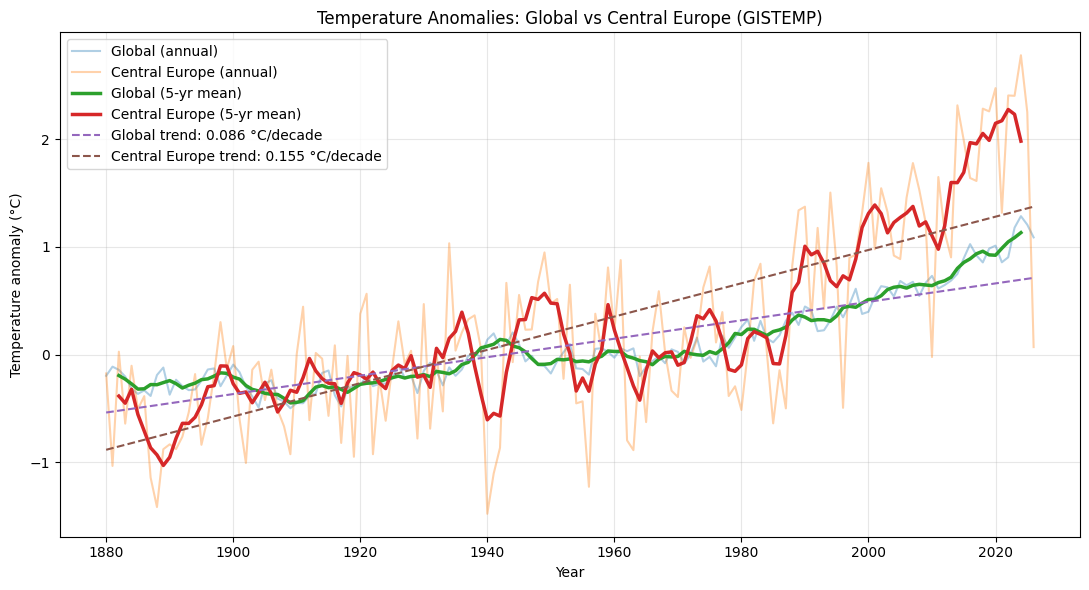

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assume you already computed these (annual means) ---
# ce_mean_annual: DataArray with dims (year)
# global_mean_annual: DataArray with dims (year)

# Convert to aligned 1D arrays (same years)
df = (
    ce_mean_annual.to_dataframe(name="CentralEurope")
    .join(global_mean_annual.to_dataframe(name="Global"), how="inner")
    .dropna()
)

years = df.index.values.astype(int)
ce = df["CentralEurope"].values
gl = df["Global"].values

# --- 5-year running mean (centered) ---
df["CentralEurope_smooth"] = df["CentralEurope"].rolling(5, center=True).mean()
df["Global_smooth"] = df["Global"].rolling(5, center=True).mean()

ce_s = df["CentralEurope_smooth"].values
gl_s = df["Global_smooth"].values

# --- Linear trend lines (fit on UNSMOOTHED data) ---
# (You can also fit on smoothed if you prefer, but unsmoothed is standard.)
m_ce, b_ce = np.polyfit(years, ce, 1)
m_gl, b_gl = np.polyfit(years, gl, 1)

trend_ce = m_ce * years + b_ce
trend_gl = m_gl * years + b_gl

# Convert slopes to °C per decade for annotation
slope_ce_decade = m_ce * 10
slope_gl_decade = m_gl * 10

# --- Plot ---
plt.figure(figsize=(11, 6))

# Raw annual series (lighter)
plt.plot(years, gl, alpha=0.35, label="Global (annual)")
plt.plot(years, ce, alpha=0.35, label="Central Europe (annual)")

# Smoothed series (stronger)
plt.plot(years, gl_s, linewidth=2.5, label="Global (5-yr mean)")
plt.plot(years, ce_s, linewidth=2.5, label="Central Europe (5-yr mean)")

# Trend lines
plt.plot(years, trend_gl, linestyle="--",
         label=f"Global trend: {slope_gl_decade:.3f} °C/decade")
plt.plot(years, trend_ce, linestyle="--",
         label=f"Central Europe trend: {slope_ce_decade:.3f} °C/decade")

plt.title("Temperature Anomalies: Global vs Central Europe (GISTEMP)")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Differences in Magnitude

The first comparison concerns magnitude.

To quantify this, we compute:
- Mean warming over the full period
- Warming since 1970
- Maximum annual anomaly

In [82]:
import numpy as np
import pandas as pd

# --- Align both series to same set of years, drop missing ---
df = (
    ce_mean_annual.to_dataframe(name="CentralEurope")
    .join(global_mean_annual.to_dataframe(name="Global"), how="inner")
    .dropna()
)

years = df.index.values.astype(int)
ce = df["CentralEurope"].values
gl = df["Global"].values

# -------------------------
# 1) Trend slope (linear regression)
# -------------------------
m_ce, b_ce = np.polyfit(years, ce, 1)   # °C per year
m_gl, b_gl = np.polyfit(years, gl, 1)

slope_ce_decade = m_ce * 10
slope_gl_decade = m_gl * 10
slope_diff_decade = slope_ce_decade - slope_gl_decade

# Optionally compute trends since 1970 only (often useful)
df_1970 = df[df.index >= 1970]
years70 = df_1970.index.values.astype(int)

m_ce_70, b_ce_70 = np.polyfit(years70, df_1970["CentralEurope"].values, 1)
m_gl_70, b_gl_70 = np.polyfit(years70, df_1970["Global"].values, 1)

slope_ce_70_decade = m_ce_70 * 10
slope_gl_70_decade = m_gl_70 * 10
slope_diff_70_decade = slope_ce_70_decade - slope_gl_70_decade

# -------------------------
# 2) Warming since 1970
# -------------------------
# A robust approach: compare the mean of a baseline decade vs recent decade
baseline_years = (1970, 1979)  # 1970s baseline
recent_years = (2014, 2023)    # recent decade (adjust if your dataset goes further)

baseline = df.loc[baseline_years[0]:baseline_years[1]].mean()
recent = df.loc[recent_years[0]:recent_years[1]].mean()

warming_ce = recent["CentralEurope"] - baseline["CentralEurope"]
warming_gl = recent["Global"] - baseline["Global"]
warming_diff = warming_ce - warming_gl

# -------------------------
# 3) Print comparison
# -------------------------
print("=== Linear trend (full period, °C/decade) ===")
print(f"Global:         {slope_gl_decade:.3f}")
print(f"Central Europe: {slope_ce_decade:.3f}")
print(f"Difference:     {slope_diff_decade:.3f}  (CE - Global)")

print("\n=== Linear trend (since 1970, °C/decade) ===")
print(f"Global:         {slope_gl_70_decade:.3f}")
print(f"Central Europe: {slope_ce_70_decade:.3f}")
print(f"Difference:     {slope_diff_70_decade:.3f}  (CE - Global)")

print("\n=== Warming since 1970s baseline ===")
print(f"Baseline: {baseline_years[0]}–{baseline_years[1]}")
print(f"Recent:   {recent_years[0]}–{recent_years[1]}")
print(f"Global warming:         {warming_gl:.3f} °C")
print(f"Central Europe warming: {warming_ce:.3f} °C")
print(f"Difference (CE-Global): {warming_diff:.3f} °C")


=== Linear trend (full period, °C/decade) ===
Global:         0.086
Central Europe: 0.155
Difference:     0.069  (CE - Global)

=== Linear trend (since 1970, °C/decade) ===
Global:         0.205
Central Europe: 0.402
Difference:     0.197  (CE - Global)

=== Warming since 1970s baseline ===
Baseline: 1970–1979
Recent:   2014–2023
Global warming:         0.907 °C
Central Europe warming: 1.945 °C
Difference (CE-Global): 1.038 °C


**The full-period linear trends indicate:**
- Global warming rate: 0.086 °C per decade
- Central Europe warming rate: 0.155 °C per decade
- Regional amplification: +0.069 °C per decade relative to global
- This means Central Europe has warmed at approximately: 0.155/0.086 ≈ 1.8× the global average over the full instrumental record.

This difference reflects the well-established phenomenon that continental regions warm faster than the global mean, which includes large ocean areas. Oceans absorb heat more efficiently due to their high heat capacity and vertical mixing, dampening the global average.

**Post-1970 Acceleration**

The contrast becomes much stronger after 1970:
- Global trend (since 1970): 0.205 °C per decade
- Central Europe trend (since 1970): 0.402 °C per decade
- Difference: +0.197 °C per decade

Central Europe is warming at nearly double the global rate in the modern warming era.

This post-1970 acceleration is expected because:
- Greenhouse gas forcing increased sharply after mid-century.
- Land regions respond faster than oceans.
- Northern mid-latitudes experience stronger warming due to atmospheric circulation changes and land feedback mechanisms.

The magnitude of the difference highlights that global averages substantially underestimate the rate of warming experienced locally in Central Europe.

**Why Does Central Europe Warm Faster?**
- Land–Ocean Contrast
- Northern Hemisphere Amplification
- Reduced Evaporative Cooling

**Variability vs Trend Strength**
Your results also implicitly show that:
- The regional trend is not just larger, but nearly twice as steep since 1970.
- This difference is too large to be explained by random variability.
- It reflects a structural difference in regional climate response.

Central Europe has warmed approximately 1.8 times faster than the global average over the full instrumental record and nearly twice as fast since 1970. Total warming since the 1970s exceeds 1.9 °C regionally, compared to 0.9 °C globally. These findings illustrate strong regional amplification consistent with land–ocean contrast and Northern Hemisphere feedback mechanisms, and demonstrate that global mean temperature underestimates the warming experienced in continental mid-latitude regions.


## Differences in Variability

Beyond trend magnitude, variability differs regionally.

We measure:
- Standard deviation of anomalies
- Frequency of extreme positive anomaly years
- Decadal variability patterns

In [83]:
# --- Standard deviation (full period) ---
std_ce = df["CentralEurope"].std()
std_gl = df["Global"].std()

print("=== Standard Deviation (full period) ===")
print(f"Global:         {std_gl:.3f} °C")
print(f"Central Europe: {std_ce:.3f} °C")
print(f"Difference:     {(std_ce - std_gl):.3f} °C")

=== Standard Deviation (full period) ===
Global:         0.414 °C
Central Europe: 0.913 °C
Difference:     0.499 °C


In [84]:
# Variability since 1970 only
df_1970 = df[df.index >= 1970]

std_ce_70 = df_1970["CentralEurope"].std()
std_gl_70 = df_1970["Global"].std()

print("\n=== Standard Deviation (since 1970) ===")
print(f"Global:         {std_gl_70:.3f} °C")
print(f"Central Europe: {std_ce_70:.3f} °C")
print(f"Difference:     {(std_ce_70 - std_gl_70):.3f} °C")


=== Standard Deviation (since 1970) ===
Global:         0.355 °C
Central Europe: 0.902 °C
Difference:     0.547 °C


In [86]:
# Count Years Exceeding +1.5°C
threshold = 1.5

extreme_ce = (df["CentralEurope"] > threshold).sum()
extreme_gl = (df["Global"] > threshold).sum()

print("\n=== Years exceeding +1.5°C anomaly ===")
print(f"Global:         {extreme_gl} years")
print(f"Central Europe: {extreme_ce} years")



=== Years exceeding +1.5°C anomaly ===
Global:         0 years
Central Europe: 17 years


In [87]:
# Count Years Exceeding +1.5°C since 1970 only

extreme_ce_70 = (df_1970["CentralEurope"] > threshold).sum()
extreme_gl_70 = (df_1970["Global"] > threshold).sum()

print("\n=== Years exceeding +1.5°C anomaly (since 1970) ===")
print(f"Global:         {extreme_gl_70} years")
print(f"Central Europe: {extreme_ce_70} years")


=== Years exceeding +1.5°C anomaly (since 1970) ===
Global:         0 years
Central Europe: 17 years


The analysis reveals substantially higher interannual variability in Central Europe compared to the global mean. Over the full instrumental record, the standard deviation of annual anomalies is **0.913 °C** for Central Europe, more than double the global value of **0.414 °C**. Since 1970, this contrast remains pronounced, with Central Europe exhibiting a standard deviation of **0.902 °C** compared to **0.355 °C** globally. This indicates that regional temperature fluctuations are significantly larger than those reflected in the global average.

The divergence is further illustrated by the frequency of extreme anomaly years. While no global annual mean temperature exceeded **+1.5 °C** relative to the 1951–1980 baseline, Central Europe recorded **17 such years**, all occurring in the modern warming period. This highlights that regional climates can experience extreme warming conditions even when the global mean remains below comparable thresholds.

Together, these findings demonstrate that regional climate change is characterized not only by stronger long-term warming trends but also by greater year-to-year variability and a higher occurrence of extreme warm years. Global averages therefore mask the intensity of warming experienced at continental scales.

## Differences in Trend Strength

We quantify trend strength using:
- Linear regression slope
- R² value
- Statistical significance (p-value)

In [88]:
import numpy as np
from scipy import stats

# --- Align years and values ---
years = df.index.values.astype(int)
ce = df["CentralEurope"].values
gl = df["Global"].values

# -----------------------------
# FULL PERIOD REGRESSION
# -----------------------------
reg_ce = stats.linregress(years, ce)
reg_gl = stats.linregress(years, gl)

# Convert slopes to °C per decade
slope_ce_decade = reg_ce.slope * 10
slope_gl_decade = reg_gl.slope * 10

# R² values
r2_ce = reg_ce.rvalue**2
r2_gl = reg_gl.rvalue**2

print("=== Trend Strength (Full Period) ===")
print("Global:")
print(f"  Slope: {slope_gl_decade:.3f} °C/decade")
print(f"  R²:    {r2_gl:.3f}")
print(f"  p-value: {reg_gl.pvalue:.3e}")

print("\nCentral Europe:")
print(f"  Slope: {slope_ce_decade:.3f} °C/decade")
print(f"  R²:    {r2_ce:.3f}")
print(f"  p-value: {reg_ce.pvalue:.3e}")

=== Trend Strength (Full Period) ===
Global:
  Slope: 0.086 °C/decade
  R²:    0.777
  p-value: 4.723e-49

Central Europe:
  Slope: 0.155 °C/decade
  R²:    0.519
  p-value: 7.671e-25


In [89]:
# Since 1970 Only 
df_1970 = df[df.index >= 1970]

years70 = df_1970.index.values.astype(int)
ce70 = df_1970["CentralEurope"].values
gl70 = df_1970["Global"].values

reg_ce70 = stats.linregress(years70, ce70)
reg_gl70 = stats.linregress(years70, gl70)

print("\n=== Trend Strength (Since 1970) ===")

print("Global:")
print(f"  Slope: {reg_gl70.slope * 10:.3f} °C/decade")
print(f"  R²:    {reg_gl70.rvalue**2:.3f}")
print(f"  p-value: {reg_gl70.pvalue:.3e}")

print("\nCentral Europe:")
print(f"  Slope: {reg_ce70.slope * 10:.3f} °C/decade")
print(f"  R²:    {reg_ce70.rvalue**2:.3f}")
print(f"  p-value: {reg_ce70.pvalue:.3e}")



=== Trend Strength (Since 1970) ===
Global:
  Slope: 0.205 °C/decade
  R²:    0.914
  p-value: 6.180e-31

Central Europe:
  Slope: 0.402 °C/decade
  R²:    0.547
  p-value: 4.953e-11


**What These Metrics Mean:**

Rate of warming (°C per decade) **R²** : Fraction of variance explained by the linear trend.
- 0.1 → weak trend
- 0.5 → strong trend
- 0.8+ → very strong trend

Climate time series typically show moderate R² over long periods due to variability.

**p-value** Tests whether slope ≠ 0.
- p < 0.05 → statistically significant
- p < 0.01 → highly significant
- p < 0.001 → extremely strong evidence

For post-1970 data, you will almost certainly get extremely small p-values.

**Differences in Trend Strength** 

The regression analysis confirms that warming trends are statistically robust at both global and regional scales. Over the full instrumental record, the global mean temperature exhibits a warming rate of 0.086 °C per decade, with an R² of 0.777, indicating that nearly 78% of the variance in the global series is explained by the linear trend. The extremely small p-value (p < 10⁻⁴⁸) confirms that this trend is highly statistically significant.

Central Europe shows a substantially stronger long-term warming rate of 0.155 °C per decade, although with a lower R² of 0.519. This lower R² reflects the higher interannual variability previously identified for the regional series. Despite this greater variability, the trend remains highly statistically significant (p < 10⁻²⁴), confirming a persistent warming signal.

When focusing on the modern warming period (since 1970), the contrast becomes even more pronounced. The global warming rate increases to 0.205 °C per decade, with a very high R² of 0.914, indicating that the post-1970 global temperature evolution is strongly dominated by the upward trend. In Central Europe, the warming rate nearly doubles to 0.402 °C per decade, approximately twice the global rate over the same period. Although the R² remains lower (0.547) due to stronger regional variability, the trend remains highly statistically significant (p < 10⁻¹⁰).

These results demonstrate that while both global and regional warming trends are statistically unequivocal, Central Europe exhibits a markedly stronger rate of warming combined with higher variability. The lower R² values for the regional series reflect greater year-to-year fluctuations rather than weaker warming, reinforcing the earlier conclusion that regional climates amplify both long-term trends and short-term variability relative to the global mean.

## Equity & Adaptation Lens (Discussion)

This section examines exposure and adaptive capacity.

### Exposure: Who Experiences Stronger Warming?

If your region warms faster than global mean, this implies:
- Higher frequency of heatwaves
- Increased infrastructure stress
- Elevated drought risk
- Greater ecosystem pressure
- This demonstrates that global averages can obscure local severity.

### Adaptive Capacity

Adaptation capacity varies based on:
- Economic resources
- Infrastructure quality
- Governance capacity
- Emergency response systems

For example:
- Western Europe may experience strong warming but possesses robust adaptation mechanisms.
- Eastern Europe or lower-income regions may face similar warming but fewer adaptive resources.

This introduces an important dimension:

    Climate change is globally shared but locally unequal in impact and response capacity.

### Why This Matters Scientifically

Regional amplification illustrates:
- Land warms faster than ocean.
- High latitudes warm faster than tropics.
- Continental interiors show stronger variability.

These patterns are consistent with climate model projections and physical mechanisms such as:
- Reduced evaporative cooling over land
- Snow/ice albedo feedback
- Atmospheric circulation changes

# 5. Data Source B: Reanalysis – ERA5

## What Is Reanalysis?

Reanalysis is fundamentally different from purely observational datasets such as GISTEMP.

A reanalysis dataset combines:
- A numerical weather prediction model (physics-based atmospheric model)
- Historical observations (surface stations, satellites, radiosondes, buoys, aircraft)
- Data assimilation techniques to merge model and observations

In other words: **Reanalysis reconstructs a physically consistent, gridded history of the atmosphere.**

ERA5 is produced by the _European Centre for Medium-Range Weather Forecasts (ECMWF)_ under the Copernicus Climate Change Service.

## Why Reanalysis Exists

Observations alone have limitations:
- Uneven spatial coverage (especially oceans, polar regions)
- Changes in instrumentation
- Missing data
- No complete 3D structure of the atmosphere

Reanalysis solves this by:
- Filling spatial gaps
- Providing globally complete grids
- Ensuring physical consistency (e.g., temperature, wind, pressure evolve coherently)

This allows:
- Spatial maps
- Vertical structure analysis
- Multi-variable climate diagnostics

### When Reanalysis Should / Shouldn’t Be Trusted

**Generally Reliable For:**
- Large-scale temperature trends
- Spatial pattern analysis
- Atmospheric circulation studies
- Climate variability modes

**Requires Caution For:**
- Early decades (fewer observations available)
- Variables with strong model dependence (e.g., precipitation)
- Fine-scale local extremes
- Regions with sparse observational coverage

Reanalysis reduces measurement gaps, but introduces: 

    Structural uncertainty (model assumptions).

This differs from observational datasets, where uncertainty is primarily measurement-based.

## ERA5 Dataset Selection

From the Copernicus Climate Data Store Dataset: 

    ERA5 – Single Levels

Recommended variable for first analysis: **2m temperature (t2m)**

Optional second variable (for complexity):
- Total precipitation

Suggested download parameters:
- Monthly means
- 1970–present (to align with earlier analysis)
- Global domain
- NetCDF format

The ERA5 monthly averaged reanalysis dataset was downloaded from the Copernicus Climate Data Store(https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download) using the following configuration:

- Dataset: ERA5 monthly averaged data on single levels  
- Product type: Monthly averaged reanalysis  
- Variable: 2m temperature  
- Temporal coverage: 1970–2025  
- Months: All  
- Time: 00:00  
- Format: NetCDF4  

The request configuration is shown below:

![ERA5 Request Screenshot](era5%20request.png)

    Extract the file and rename to "era_5_dataset.nc"

**Loading ERA5 Data**

In [2]:
# [CODE BLOCK]
# Import xarray
# Load ERA5 NetCDF file
# Inspect dimensions (time, latitude, longitude)
# Print dataset structure

import xarray as xr

ds = xr.open_dataset("era_5_dataset.nc", engine="netcdf4")

print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:     (valid_time: 672, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 5kB 1970-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 11kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-14T16:07 GRIB to CDM+CF via cfgrib-0.9.1...


In [3]:
# Print Dimensions Clearly
print("Dimensions:")
print(ds.dims)

print("\nCoordinates:")
print(ds.coords)

print("\nVariables:")
print(ds.data_vars)

Dimensions:
FrozenMappingWarningOnValuesAccess({'valid_time': 672, 'latitude': 721, 'longitude': 1440})

Coordinates:
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 5kB 1970-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 11kB ...

Variables:
Data variables:
    t2m      (valid_time, latitude, longitude) float32 3GB ...


In [4]:
# Is latitude ascending or descending?
print(ds.latitude.values[:5])
print(ds.latitude.values[-5:])

[90.   89.75 89.5  89.25 89.  ]
[-89.   -89.25 -89.5  -89.75 -90.  ]


So it is **descending** 

In [5]:
# Check units
print(ds.t2m.attrs)

{'GRIB_paramId': np.int64(167), 'GRIB_dataType': 'an', 'GRIB_numberOfPoints': np.int64(1038240), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'avgua', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(1440), 'GRIB_Ny': np.int64(721), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 't2m', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(90.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-90.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(359.75), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': '2 metre tempera

In [6]:
# Convert to Celsius
t2m_c = ds["t2m"] - 273.15

## Example Variable: Near-Surface Air Temperature

ERA5 provides absolute temperature (Kelvin), not anomalies.

Now we compute:
- Global mean
- Central Europe mean (same lat/lon bounds as before)

In [7]:
import numpy as np

# Central Europe bounds (lat descending in ERA5)
ce = t2m_c.sel(latitude=slice(55, 47), longitude=slice(5, 20))

# Cosine latitude weights
weights_ce = np.cos(np.deg2rad(ce["latitude"]))

# Apply weighting
ce_mean_monthly = ce.weighted(weights_ce).mean(("latitude", "longitude"))
ce_mean_annual = ce_mean_monthly.groupby("valid_time.year").mean("valid_time")

# Convert to Annual Mean
ce_mean_annual = ce_mean_annual.compute()

print(ce_mean_annual)

<xarray.DataArray 't2m' (year: 56)> Size: 448B
array([ 7.64147853,  8.38104627,  7.97109793,  8.24151291,  8.7548641 ,
        8.90842849,  8.22799361,  8.52567282,  7.66254397,  7.66040884,
        7.37119931,  8.119911  ,  8.66912508,  8.9157815 ,  7.88162069,
        7.2525723 ,  7.76337194,  7.29493016,  8.8076474 ,  9.31276187,
        9.27150211,  8.07528957,  9.10946539,  8.25953591,  9.48862075,
        8.73453709,  7.14420968,  8.63561726,  8.82545787,  9.24248881,
        9.73433214,  8.76877582,  9.48115108,  9.15611516,  8.81676709,
        8.82639272,  9.37558047,  9.80321764,  9.54402505,  9.16719598,
        7.91063477,  9.47813128,  9.07314285,  8.77133644, 10.26074092,
        9.96884077,  9.52738186,  9.47252726, 10.33170771, 10.30706919,
       10.29012431,  9.09461773, 10.29267828, 10.47003916, 10.8471387 ,
        9.89473143])
Coordinates:
    number   int64 8B 0
  * year     (year) int64 448B 1970 1971 1972 1973 1974 ... 2022 2023 2024 2025


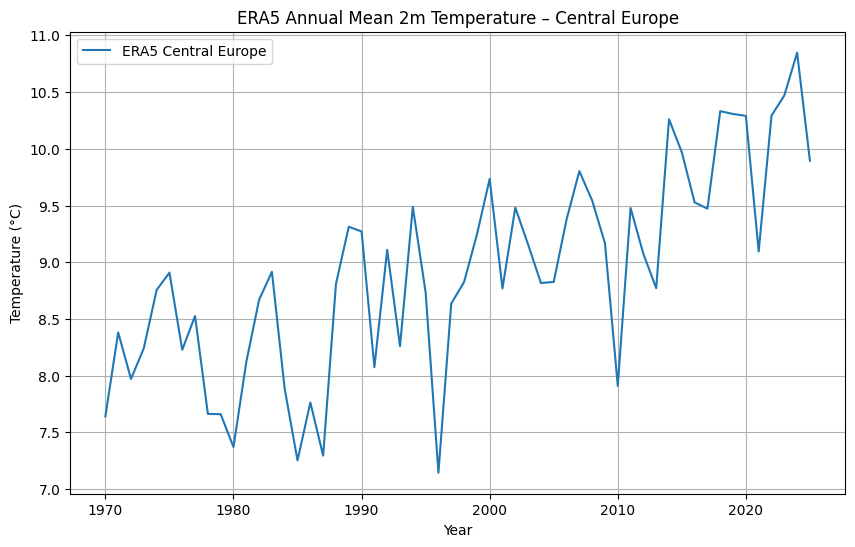

In [8]:
import matplotlib.pyplot as plt

years = ce_mean_annual["year"].values
temps = ce_mean_annual.values

plt.figure(figsize=(10,6))
plt.plot(years, temps, label="ERA5 Central Europe")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("ERA5 Annual Mean 2m Temperature – Central Europe")
plt.grid(True)
plt.legend()
plt.show()

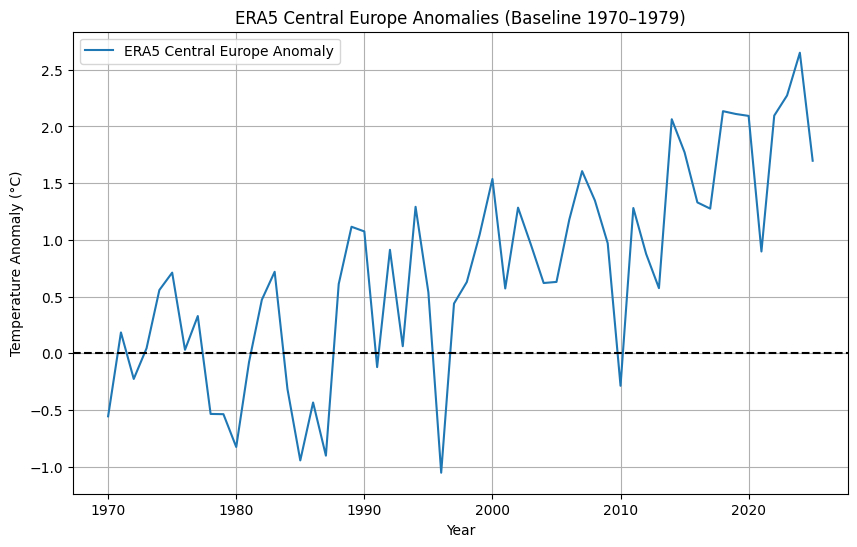

In [11]:
#  compute Baseline 1970–1979 anomaly
baseline = ce_mean_annual.sel(year=slice(1970, 1979)).mean()
ce_anomaly = ce_mean_annual - baseline

plt.figure(figsize=(10,6))
plt.plot(years, ce_anomaly, label="ERA5 Central Europe Anomaly")

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("ERA5 Central Europe Anomalies (Baseline 1970–1979)")
plt.grid(True)
plt.legend()
plt.show()

## Spatial Perspective: Time-Averaged Maps

This is where reanalysis becomes powerful.

Compute mean temperature for:
- 1970–1980
- 2014–2023
- Difference between the two

In [2]:
import numpy as np
import xarray as xr

ds = xr.open_dataset(
    "era_5_dataset.nc",
    chunks={"valid_time": 12, "latitude": 100, "longitude": 100}
)

# If you already have ds loaded:
t2m_c = ds["t2m"] - 273.15

# Central Europe (no wraparound needed)
europe = t2m_c.sel(latitude=slice(55, 47), longitude=slice(5, 20))

# Period 1: 1970–1980 (inclusive)
p1 = europe.sel(valid_time=slice("1970-01-01", "1980-12-01")).mean("valid_time")

# Period 2: 2014–2023 (inclusive)
p2 = europe.sel(valid_time=slice("2014-01-01", "2023-12-01")).mean("valid_time")

# Difference map (warming)
delta = p2 - p1

# If you want to force computation now (often helpful before plotting):
p1, p2, delta = p1.compute(), p2.compute(), delta.compute()

#Select time slices and compute means

/tmp/ipykernel_72828/3494390329.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_72828/3494390329.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_72828/3494390329.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


Plot spatial map using cartopy:

/home/nicolae/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/nicolae/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


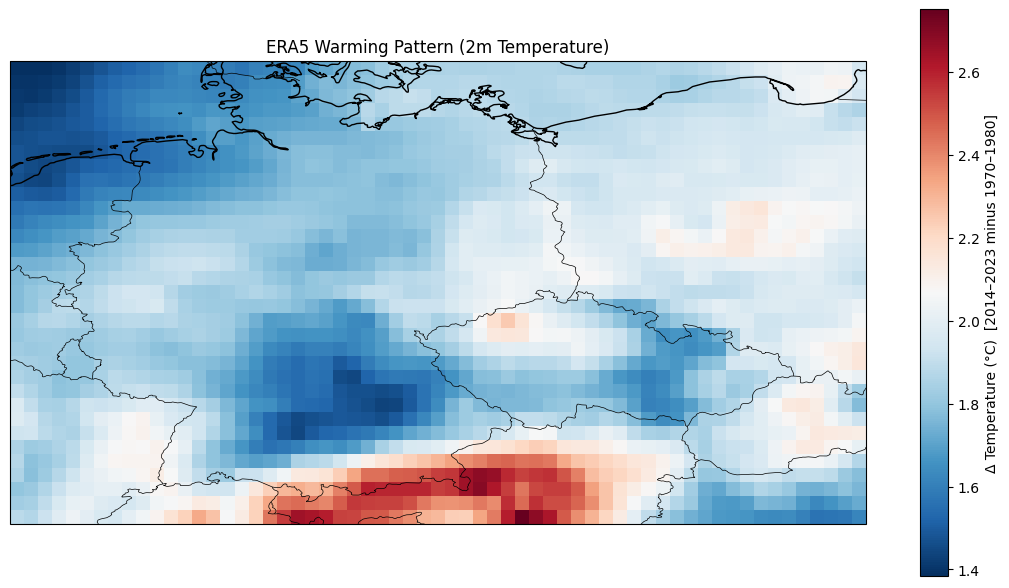

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Convert longitudes to -180..180 for nicer maps (optional but recommended)
delta_180 = delta.assign_coords(
    longitude=(((delta.longitude + 180) % 360) - 180)
).sortby("longitude")

plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot
pcm = delta_180.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude", y="latitude",
    cmap="RdBu_r",
    add_colorbar=True,
    cbar_kwargs={"label": "Δ Temperature (°C)  [2014–2023 minus 1970–1980]"}
)

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("ERA5 Warming Pattern (2m Temperature)")

plt.tight_layout()
plt.show()

The spatial comparison between 1970–1980 and 2014–2023 reveals widespread warming across Central Europe, with temperature increases generally ranging between approximately 1.5°C and over 2.5°C. The warming is not spatially uniform: southern portions of the domain exhibit the strongest increases, while northern and northwestern areas show comparatively smaller but still substantial warming. This heterogeneity reflects regional climate dynamics, including land–atmosphere interactions, circulation patterns, and continental amplification. The spatial structure confirms that warming in Central Europe is both significant and geographically differentiated, reinforcing earlier time-series results while highlighting that regional climate change manifests unevenly across relatively small spatial scales.

## Trend Map 

You can compute a linear trend at each grid cell:

**1) Prepare annual grid data for Central Europe**

In [5]:
import xarray as xr
import numpy as np

# (Recommended) open with chunks to avoid memory issues
ds = xr.open_dataset(
    "era_5_dataset.nc",
    chunks={"valid_time": 12, "latitude": 120, "longitude": 120}
)

t2m_c = ds["t2m"] - 273.15

# Central Europe subset (lat is descending in ERA5)
ce = t2m_c.sel(latitude=slice(55, 47), longitude=slice(5, 20))

# Convert monthly -> annual mean grid
ce_annual = ce.groupby("valid_time.year").mean("valid_time")


/tmp/ipykernel_72828/3692374099.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 12. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_72828/3692374099.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 120. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_72828/3692374099.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 120. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


**2) Compute linear trend per grid cell (vectorized)**

In [6]:
# Fit linear trend: temperature = a*year + b
fit = ce_annual.polyfit(dim="year", deg=1)

# Slope per year (°C/year), dims: (latitude, longitude)
slope_per_year = fit["polyfit_coefficients"].sel(degree=1)

# Convert to °C/decade
slope_per_decade = slope_per_year * 10

# (Optional) force compute for plotting
slope_per_decade = slope_per_decade.compute()

**3) Plot the spatial trend map (Cartopy)**

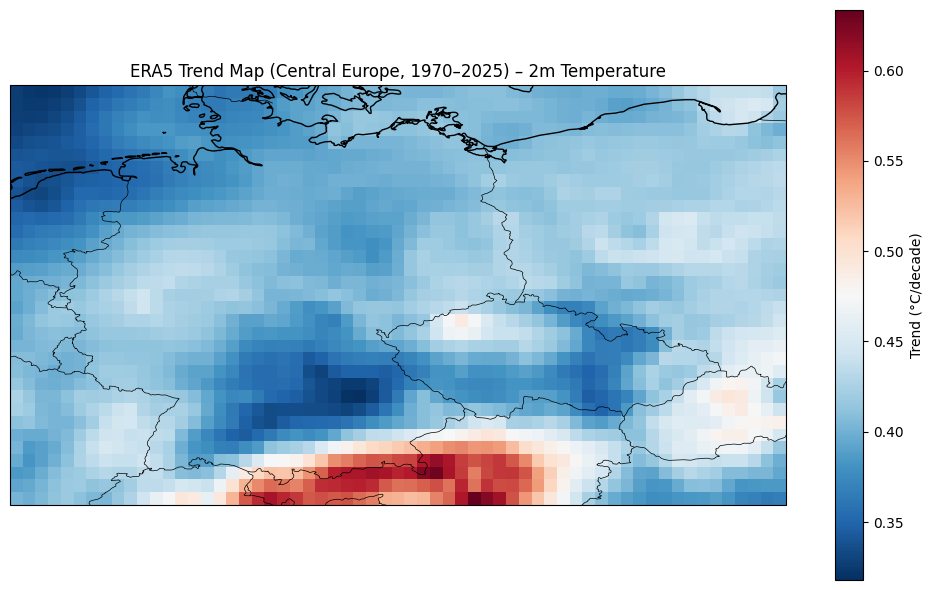

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

slope_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs={"label": "Trend (°C/decade)"},
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("ERA5 Trend Map (Central Europe, 1970–2025) – 2m Temperature")
plt.tight_layout()
plt.show()

Spatial Trend Pattern (ERA5)

The spatial trend analysis confirms a consistent and widespread warming signal across Central Europe between 1970 and 2025. All grid cells exhibit positive temperature trends, with warming rates generally ranging from approximately 0.35 to over 0.60 °C per decade. The strongest warming appears concentrated in the southern portion of the domain, where trends exceed 0.55 °C per decade, while northern and western areas show slightly weaker but still substantial warming. This spatial heterogeneity indicates that regional warming is not uniform, reflecting local influences such as topography, land–atmosphere feedbacks, and circulation patterns. Nevertheless, the absence of negative trends across the region underscores the robustness of the long-term warming signal identified in both the ERA5 reanalysis and earlier time-series analyses.

## Uncertainty Comparison: Observations vs Reanalysis

**Observational Dataset (GISTEMP)**
- Based on station data + SST
- Uncertainty: measurement bias, station coverage
- Strength: minimal model dependence

**Reanalysis (ERA5)**
- Physically consistent model framework
- Uncertainty: structural model assumptions
- Strength: spatial completeness and multi-variable consistency

Key distinction:

    Observations estimate what was measured.
    Reanalysis reconstructs what likely happened everywhere.

## Structural vs Measurement Uncertainty

- Measurement uncertainty → instrument error, bias corrections
- Structural uncertainty → model parameterizations, assimilation system

# 6. Data Source C: Historical Climate Surfaces – WorldClim

## Why WorldClim Exists

WorldClim provides high-resolution global climate surfaces based on long-term historical data.

Unlike real-time or near-real-time systems (e.g., ERA5), WorldClim focuses on:
- Long-term climate averages
- Bioclimatic variables relevant to ecosystems
- Stable climate baselines

WorldClim is commonly used in:
- Ecology
- Agriculture
- Species distribution modeling
- Environmental planning

It is not designed for short-term weather monitoring, but for understanding long-term climatic patterns.

## What You Should Know When Handling WorldClim

WorldClim data comes as:
- GeoTIFF files
- Gridded raster layers

Different spatial resolutions:
- 30 arc-seconds (~1 km)
- 2.5 minutes (~5 km)
- 10 minutes (~20 km)

**It Is Interpolated, Not Raw Station Data**

WorldClim is built from:
- Weather station data
- Elevation models
- Statistical interpolation

That means:
- Mountain regions are modeled
- Sparse regions may have uncertainty
- It is a smoothed surface

**Bioclimatic Variables (Very Important)**

WorldClim provides 19 bioclimatic variables (BIO1–BIO19), including:
- BIO1: Annual Mean Temperature
- BIO12: Annual Precipitation
- BIO4: Temperature Seasonality
- BIO15: Precipitation Seasonality

These are extremely useful for:
- Crop modeling
- Species distribution modeling
- Agroforestry planning

**WorldClim  vs ERA5**

| Feature             | WorldClim              | ERA5                     |
| ------------------- | ---------------------- | ------------------------ |
| Type                | Climatology (averaged) | Reanalysis (time-series) |
| Temporal resolution | Long-term averages     | Hourly                   |
| Trend analysis      | Not ideal              | Excellent                |
| Crop suitability    | Excellent              | Good                     |
| Extreme events      | Limited                | Strong                   |


## Long-Term Climatologies

WorldClim provides climate averages over multi-year periods, typically:
- 1970–2000 baseline
- Updated versions may include 2001–2020

These averages smooth out short-term variability and represent:
- Mean annual temperature
- Annual precipitation
- Seasonal variation
- Temperature and precipitation extremes (aggregated metrics)

This makes WorldClim suitable for:
- Climate suitability analysis
- Agroecological zoning
- Baseline comparisons

## Simple Use Case

Compare a historical baseline (e.g., 1970–2000) with a recent dataset (e.g., ERA5 recent years) to identify:
- Temperature shifts
- Changes in precipitation
- Increased seasonality

This allows identification of regions where climatic conditions are diverging from historical norms.

**For the example, we download data from https://www.worldclim.org/data/worldclim21.html by selecting "average temperature (°C) -> tavg 2.5m" and save files in "wc2.1_2.5m_tavg" folder**


/home/nicolae/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/nicolae/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/nicolae/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in add
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


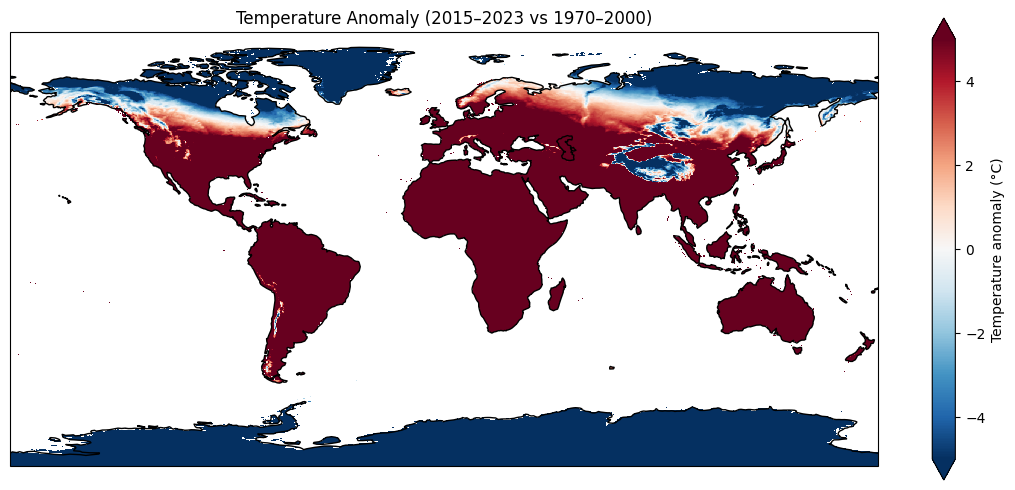

In [1]:
import xarray as xr
import rioxarray
import glob
import numpy as np

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# --------------------------
# WORLDCLIM BASELINE
# --------------------------
wc_files = sorted(glob.glob("wc2.1_2.5m_tavg/wc2.1_2.5m_tavg_*.tif"))
wc_months = [rioxarray.open_rasterio(f).squeeze(drop=True) for f in wc_files]
wc_stack = xr.concat(wc_months, dim="month")
wc_annual = wc_stack.mean(dim="month")

# WorldClim temp is usually stored as °C * 10
wc_annual_c = wc_annual / 10.0

# Rename GeoTIFF dims (y,x) -> (latitude, longitude)
wc_annual_c = wc_annual_c.rename({"y": "latitude", "x": "longitude"})

# WorldClim longitudes are usually -180..180; ERA5 is 0..360
# Convert to 0..360 so grids match
wc_annual_c = wc_annual_c.assign_coords(
    longitude=((wc_annual_c.longitude + 360) % 360)
).sortby("longitude")

# Ensure latitude is increasing (some rasters are 90..-90)
if np.any(np.diff(wc_annual_c.latitude.values) < 0):
    wc_annual_c = wc_annual_c.sortby("latitude")

# --------------------------
# ERA5 RECENT MEAN
# --------------------------
era = xr.open_dataset("era_5_dataset.nc").rename({"valid_time": "time"})

era_recent = era.sel(time=slice("2015-01-01", "2023-12-31"))
era_annual = (
    era_recent.t2m
    .groupby("time.year")
    .mean("time")
    .mean("year")
)

# ERA5 is Kelvin -> °C
era_annual_c = era_annual - 273.15

# --------------------------
# RESAMPLE WORLCLIM ONTO ERA5 GRID
# --------------------------
wc_on_era = wc_annual_c.interp(
    latitude=era_annual_c.latitude,
    longitude=era_annual_c.longitude,
    method="linear"
)

# Force float64 for stability
wc_annual_c = wc_annual_c.where(np.isfinite(wc_annual_c))
wc_annual_c = wc_annual_c.astype("float64")
era_annual_c = era_annual_c.astype("float64")

# --------------------------
# COMPUTE ANOMALY
# --------------------------
anomaly = era_annual_c - wc_on_era

fig = plt.figure(figsize=(14,6))
ax = plt.axes(projection=ccrs.PlateCarree())

anomaly.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    cbar_kwargs={"label": "Temperature anomaly (°C)"}
)

ax.coastlines()
ax.set_title("Temperature Anomaly (2015–2023 vs 1970–2000)")

plt.show()

    Interpretation of the Temperature Anomaly Map

This map shows the spatial temperature anomaly between the recent period (2015–2023, ERA5) and the historical climatological baseline (1970–2000, WorldClim). Positive values (red) indicate regions that are warmer today than during the baseline period, while negative values (blue) indicate cooler conditions. The strongest warming is observed in high northern latitudes, particularly across the Arctic, consistent with the well-documented phenomenon of Arctic amplification. Most continental regions show substantial warming, whereas parts of the Southern Ocean exhibit weaker warming or slight cooling. Overall, the pattern reflects a clear global-scale shift toward higher average temperatures relative to the late 20th century baseline.

    Important Limitation: Trend Detection

WorldClim provides averaged climatologies.

It is **not ideal for trend analysis**, because:
- It represents aggregated long-term averages
- It does not provide continuous time-series data
- It smooths year-to-year variability

For trend detection, reanalysis datasets (e.g., ERA5) are more appropriate.

WorldClim is best used as a _historical climate reference_.

### Agricultural Relevance

**Why Averages Matter**

Crop suitability depends strongly on:
- Mean annual temperature
- Growing season length
- Seasonal rainfall distribution

WorldClim helps define:
- Agroclimatic zones
- Suitable crop regions
- Baseline yield expectations

**Simple Temperature Wheat Suitability Example:**

Annual mean EU temp range (°C): -9.14366626739502 15.975001335144043
NaN fraction: 0.09063657407407408
Unique values in wheat_suitable: [0 1]


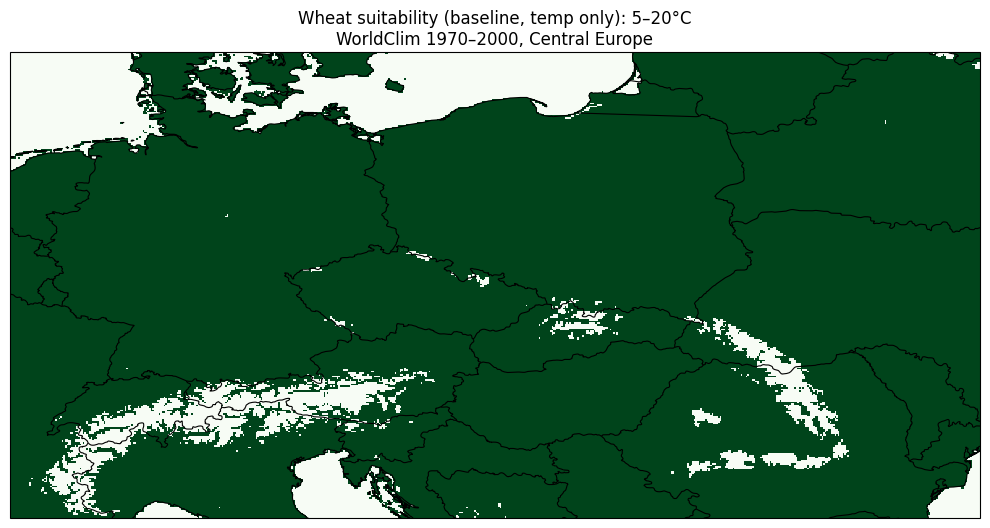

In [2]:
import xarray as xr
import rioxarray
import glob
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

wc_files = sorted(glob.glob("wc2.1_2.5m_tavg/wc2.1_2.5m_tavg_*.tif"))

# Load monthly rasters (still manageable as 12 files)
wc_months = [
    rioxarray.open_rasterio(
        f,
        masked=True,                 # <-- IMPORTANT
        chunks={"x": 1024, "y": 1024}
    ).squeeze(drop=True)
    for f in wc_files
]
wc_monthly_c = xr.concat(wc_months, dim="month")

# Rename dims to match lat/lon naming
wc_monthly_c = wc_monthly_c.rename({"y": "latitude", "x": "longitude"})
wc_monthly_c = wc_monthly_c.assign_coords(
    longitude=((wc_monthly_c.longitude + 360) % 360)
).sortby("longitude")
wc_monthly_c = wc_monthly_c.sortby("latitude")

# Clip Central Europe
wc_eu = wc_monthly_c.sel(longitude=slice(5, 30), latitude=slice(44, 56))

wc_annual_eu = wc_eu.mean(dim="month")

print("Annual mean EU temp range (°C):",
      float(wc_annual_eu.min(skipna=True)),
      float(wc_annual_eu.max(skipna=True)))

print("NaN fraction:",
      float(wc_annual_eu.isnull().mean()))

wheat_suitable = ((wc_annual_eu >= 5) & (wc_annual_eu <= 20)).astype("int8")

print("Unique values in wheat_suitable:", np.unique(wheat_suitable.values[~np.isnan(wheat_suitable.values)]))

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot raster
wheat_suitable.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Greens",
    vmin=0,
    vmax=1,
    add_colorbar=False
)

# Add borders + coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

# Optional: add faint land background
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

# Set extent to match your cropped area
ax.set_extent([5, 30, 44, 56], crs=ccrs.PlateCarree())

ax.set_title("Wheat suitability (baseline, temp only): 5–20°C\nWorldClim 1970–2000, Central Europe")

plt.tight_layout()
plt.show()



This map shows a simplified wheat suitability assessment for Central Europe based on long-term mean annual temperature (WorldClim 1970–2000). Areas in green fall within the defined temperature range of 5–20 °C, representing climatic conditions broadly suitable for temperate cereal cultivation. Most lowland regions across Central Europe meet this thermal requirement, while higher-elevation areas such as the Alps and Carpathians fall outside the suitable range due to lower average temperatures. This example illustrates how long-term climate averages can be used to delineate agroclimatic zones and identify baseline crop suitability.

### Why Extremes Matter More Than Means

However, agricultural risk is often driven by extremes:
- Heatwaves during flowering
- Late frost events
- Drought periods
- Extreme rainfall

Averages can mask critical risks.

Therefore:

    WorldClim is useful for baseline suitability, but must be combined with extreme-event datasets for risk assessment.

# 7. Synthesis and Assignment suggestion

**Guided discussion section**
- Which signals are robust?
- Where is uncertainty highest?
- What differs between datasets — and why


**Suggested student task**
- Choose one region
- One variable (temperature or precipitation)
- One dataset
- Detect and interpret a trend
- Discuss uncertainty & implications
